# Análise dos Experimentos — WebKB / MPQA / Reuters90 (10-fold CV)

**Modos analisados:**
- `raw` — fine-tuning padrão, sem IS e sem CL
- `is` — Instance Selection (IS), sem CL
- `cl` — Curriculum Learning (CL), sem IS
- `is_cl` — IS + CL combinados

**Pastas usadas** (duas mais recentes por dataset; `raw` em uma, `is`/`cl`/`is_cl` na outra):

| Dataset | Run `raw` | Run `is`/`cl`/`is_cl` |
|---|---|---|
| webkb | `webkb-10cv-20260525-210416-4e200f` | `webkb-10cv-20260525-175709-4adc52` |
| mpqa | `mpqa-10cv-20260525-210358-f357ae` | `mpqa-10cv-20260525-175737-84b62d` |
| reuters90 | `reuters90-10cv-20260525-210439-d13b00` | `reuters90-10cv-20260525-175725-f78940` |

Saídas em `analysis/`:
- `performance.xlsx` — abas `macro_f1`, `micro_f1`, `accuracy`, `hard_slice_macro_f1`
- `timings.xlsx` — abas `model_train_time_s`, `total_run_time_s`

Cada aba tem 12 linhas: (dataset × modo) com fold0..fold9, média, std, IC 95% (t-student).

Para cada dataset roda um **projeto 2² (IS × CL)** sobre **macro-F1** e sobre **tempo de treino**.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from numpy.linalg import lstsq

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'analysis' else Path.cwd()
RESULTS_DIR  = PROJECT_ROOT / 'results'
OUT_DIR      = PROJECT_ROOT / 'analysis'
OUT_DIR.mkdir(exist_ok=True)

DATASETS = ['webkb', 'mpqa', 'reuters90']
MODES    = ['raw', 'is', 'cl', 'is_cl']
N_FOLDS  = 10
CI_ALPHA = 0.05  # 95% CI

MODE_LABELS = {'raw': 'Raw', 'is': 'IS', 'cl': 'CL', 'is_cl': 'IS + CL'}
MODE_COLORS = {
    'raw':   '#4C72B0',
    'is':    '#DD8452',
    'cl':    '#55A868',
    'is_cl': '#C44E52',
}

# Mapeamento dataset → fator (mode) → run dir.
# Para cada dataset escolhemos as DUAS pastas mais recentes; a que tem raw_fold0
# atende raw e a outra atende is/cl/is_cl.
def _two_latest(dataset):
    pref = f'{dataset}-10cv-'
    dirs = sorted(
        (p for p in RESULTS_DIR.iterdir() if p.is_dir() and p.name.startswith(pref)),
        key=lambda p: p.name, reverse=True,
    )
    return dirs[:2]

RUN_DIRS = {}
for ds in DATASETS:
    RUN_DIRS[ds] = {}
    for d in _two_latest(ds):
        for mode in MODES:
            if (d / f'{mode}_fold0').is_dir():
                RUN_DIRS[ds][mode] = d

for ds in DATASETS:
    print(f'{ds}:')
    for mode in MODES:
        path = RUN_DIRS[ds].get(mode)
        print(f'  {mode:6s} -> {path.name if path else "AUSENTE"}')


def ci95(values):
    """IC 95% via t-student; ignora NaN."""
    vals = np.asarray(values, dtype=float)
    vals = vals[~np.isnan(vals)]
    n = len(vals)
    if n < 2:
        return (float('nan'), float('nan'))
    m  = vals.mean()
    se = stats.sem(vals)
    h  = se * stats.t.ppf(1 - CI_ALPHA / 2, df=n - 1)
    return (m - h, m + h)

print('\nSetup concluído.')

webkb:
  raw    -> webkb-10cv-20260525-210416-4e200f
  is     -> webkb-10cv-20260525-175709-4adc52
  cl     -> webkb-10cv-20260525-175709-4adc52
  is_cl  -> webkb-10cv-20260525-175709-4adc52
mpqa:
  raw    -> mpqa-10cv-20260525-210358-f357ae
  is     -> mpqa-10cv-20260525-175737-84b62d
  cl     -> mpqa-10cv-20260525-175737-84b62d
  is_cl  -> mpqa-10cv-20260525-175737-84b62d
reuters90:
  raw    -> reuters90-10cv-20260525-210439-d13b00
  is     -> reuters90-10cv-20260525-175725-f78940
  cl     -> reuters90-10cv-20260525-175725-f78940
  is_cl  -> reuters90-10cv-20260525-175725-f78940

Setup concluído.


## 1. Carregamento dos dados e verificação de completude

In [2]:
EXPECTED_PHASES = {
    'raw':   {'full'},
    'is':    {'full'},
    'cl':    {'clean', 'diverse', 'hard'},
    'is_cl': {'clean', 'diverse', 'hard'},
}

timings_rows = []
phase_metrics_rows = []
completeness = {(ds, m): [] for ds in DATASETS for m in MODES}

for ds in DATASETS:
    for mode in MODES:
        run_dir = RUN_DIRS[ds].get(mode)
        for fold in range(N_FOLDS):
            status = 'ok'
            if run_dir is None:
                completeness[(ds, mode)].append({'fold': fold, 'status': 'sem run'})
                continue
            fold_dir = run_dir / f'{mode}_fold{fold}'

            t_file = fold_dir / 'timings.csv'
            if t_file.exists():
                t = pd.read_csv(t_file, index_col='name')['seconds'].to_dict()
                t.update({'dataset': ds, 'mode': mode, 'fold': fold})
                timings_rows.append(t)
            else:
                status = 'sem timings'

            pm_file = fold_dir / 'phase_metrics.csv'
            if pm_file.exists():
                pm = pd.read_csv(pm_file)
                pm['dataset'] = ds
                pm['mode']    = mode
                pm['fold']    = fold
                phase_metrics_rows.append(pm)
                observed = set(pm['phase'].unique())
                if not EXPECTED_PHASES[mode].issubset(observed):
                    status = f'incompleto (fases: {sorted(observed)})'
            else:
                status = 'sem phase_metrics'

            completeness[(ds, mode)].append({'fold': fold, 'status': status})

df_timings = pd.DataFrame(timings_rows)
df_pm      = pd.concat(phase_metrics_rows, ignore_index=True) if phase_metrics_rows else pd.DataFrame()

print(f'Timings carregados: {len(df_timings)} entradas')
print(f'Phase metrics:       {len(df_pm)} linhas')

Timings carregados: 112 entradas
Phase metrics:       224 linhas


### 1.1 Resumo de completude (dataset × modo)

In [3]:
rows = []
for ds in DATASETS:
    for mode in MODES:
        items = completeness[(ds, mode)]
        ok    = sum(1 for x in items if x['status'] == 'ok')
        bad   = [(x['fold'], x['status']) for x in items if x['status'] != 'ok']
        rows.append({
            'Dataset':     ds,
            'Modo':        MODE_LABELS[mode],
            'Completos':   ok,
            'Incompletos': len(bad),
            'Folds com falha': str([f for f, _ in bad]) if bad else '—',
        })
df_completeness = pd.DataFrame(rows).set_index(['Dataset', 'Modo'])
display(df_completeness)

# Conjunto de folds completos por (dataset, mode)
complete_folds = {
    (ds, m): [x['fold'] for x in completeness[(ds, m)] if x['status'] == 'ok']
    for ds in DATASETS for m in MODES
}

Completos  Incompletos Folds com falha
Dataset   Modo                                           
webkb     Raw             10            0               —
          IS              10            0               —
          CL              10            0               —
          IS + CL         10            0               —
mpqa      Raw             10            0               —
          IS              10            0               —
          CL              10            0               —
          IS + CL         10            0               —
reuters90 Raw              8            2          [1, 3]
          IS               8            2          [1, 3]
          CL               8            2          [1, 3]
          IS + CL          8            2          [1, 3]

## 2. Tabelas de desempenho e tempo (planilhas .xlsx)

12 linhas por aba = 3 datasets × 4 modos.  
Colunas: `dataset, mode, fold0..fold9, mean, std, ci95_low, ci95_high, n_used`.  
Folds sem `phase_metrics.csv`/`timings.csv` viram NaN (estatísticas usam apenas folds presentes).

In [4]:
PERF_METRICS = ['macro_f1', 'micro_f1', 'accuracy', 'hard_slice_macro_f1']
TIME_METRICS = ['model_train_time_s', 'total_run_time_s']

def fold_metric_value(ds, mode, fold, metric):
    """Última linha de phase_metrics como valor final do fold."""
    if df_pm.empty:
        return float('nan')
    sub = df_pm[(df_pm['dataset'] == ds) & (df_pm['mode'] == mode) & (df_pm['fold'] == fold)]
    if sub.empty or metric not in sub.columns:
        return float('nan')
    return float(sub[metric].iloc[-1])

def fold_time_value(ds, mode, fold, key):
    if df_timings.empty or key not in df_timings.columns:
        return float('nan')
    sub = df_timings[(df_timings['dataset'] == ds) & (df_timings['mode'] == mode) & (df_timings['fold'] == fold)]
    if sub.empty:
        return float('nan')
    val = sub.iloc[0].get(key, float('nan'))
    return float(val) if pd.notna(val) else float('nan')

def stats_row(values):
    arr = np.asarray(values, dtype=float)
    valid = arr[~np.isnan(arr)]
    n = len(valid)
    if n == 0:
        return {'mean': float('nan'), 'std': float('nan'),
                'ci95_low': float('nan'), 'ci95_high': float('nan'), 'n_used': 0}
    mean = float(valid.mean())
    std  = float(valid.std(ddof=1)) if n > 1 else 0.0
    sem  = std / np.sqrt(n) if n > 1 else 0.0
    tcrit = stats.t.ppf(1 - CI_ALPHA / 2, df=n - 1) if n > 1 else 0.0
    margin = tcrit * sem
    return {'mean': mean, 'std': std,
            'ci95_low': mean - margin, 'ci95_high': mean + margin, 'n_used': n}

def build_sheet(metric, kind):
    rows = []
    for ds in DATASETS:
        for mode in MODES:
            vals = [
                fold_metric_value(ds, mode, k, metric) if kind == 'perf'
                else fold_time_value(ds, mode, k, metric)
                for k in range(N_FOLDS)
            ]
            row = {'dataset': ds, 'mode': mode}
            for k, v in enumerate(vals):
                row[f'fold{k}'] = v
            row.update(stats_row(vals))
            rows.append(row)
    cols = ['dataset', 'mode'] + [f'fold{k}' for k in range(N_FOLDS)] + ['mean', 'std', 'ci95_low', 'ci95_high', 'n_used']
    return pd.DataFrame(rows)[cols]

perf_sheets = {m: build_sheet(m, 'perf') for m in PERF_METRICS}
time_sheets = {m: build_sheet(m, 'time') for m in TIME_METRICS}

perf_xlsx = OUT_DIR / 'performance.xlsx'
with pd.ExcelWriter(perf_xlsx, engine='openpyxl') as w:
    for name, df in perf_sheets.items():
        df.to_excel(w, sheet_name=name, index=False)

time_xlsx = OUT_DIR / 'timings.xlsx'
with pd.ExcelWriter(time_xlsx, engine='openpyxl') as w:
    for name, df in time_sheets.items():
        df.to_excel(w, sheet_name=name, index=False)

print(f'Escrito: {perf_xlsx.relative_to(PROJECT_ROOT)}')
print(f'Escrito: {time_xlsx.relative_to(PROJECT_ROOT)}')

print('\nMacro-F1 (mean ± std, IC 95%, n folds usados):')
display(perf_sheets['macro_f1'][['dataset', 'mode', 'mean', 'std', 'ci95_low', 'ci95_high', 'n_used']].round(4))

print('\nTempo de treino (s):')
display(time_sheets['model_train_time_s'][['dataset', 'mode', 'mean', 'std', 'ci95_low', 'ci95_high', 'n_used']].round(2))

Escrito: analysis/performance.xlsx
Escrito: analysis/timings.xlsx

Macro-F1 (mean ± std, IC 95%, n folds usados):


,dataset,mode,mean,std,ci95_low,ci95_high,n_used
0,webkb,raw,0.8274,0.0226,0.8112,0.8436,10
1,webkb,is,0.8073,0.0184,0.7942,0.8205,10
2,webkb,cl,0.7340,0.0219,0.7184,0.7497,10
3,webkb,is_cl,0.6994,0.0171,0.6872,0.7117,10
4,mpqa,raw,0.8963,0.0114,0.8882,0.9045,10
5,mpqa,is,0.8920,0.0085,0.8859,0.8982,10
6,mpqa,cl,0.8896,0.0128,0.8804,0.8987,10
7,mpqa,is_cl,0.8899,0.0104,0.8824,0.8974,10
8,reuters90,raw,0.4656,0.0127,0.4550,0.4762,8
9,reuters90,is,0.4331,0.0281,0.4096,0.4566,8



Tempo de treino (s):


,dataset,mode,mean,std,ci95_low,ci95_high,n_used
0,webkb,raw,1367.52,284.88,1163.73,1571.31,10
1,webkb,is,574.80,100.33,503.03,646.58,10
2,webkb,cl,475.33,46.82,441.84,508.82,10
3,webkb,is_cl,742.11,61.54,698.09,786.14,10
4,mpqa,raw,329.96,8.29,324.03,335.89,10
5,mpqa,is,125.48,10.83,117.74,133.23,10
6,mpqa,cl,126.25,12.56,117.27,135.23,10
7,mpqa,is_cl,86.14,10.88,78.36,93.93,10
8,reuters90,raw,1910.91,728.39,1301.96,2519.86,8
9,reuters90,is,887.77,144.61,766.87,1008.67,8


### 2.1 Decomposição do tempo total — WebKB

Mesma ideia da §2.3 do `analysis.ipynb` original: barra empilhada por modo com 3 componentes do `timings.csv`:

- **IS fit** (`is_fit_time_s`) — 0 para `raw` (sem BIOIS)
- **Treino do modelo** (`model_train_time_s`)
- **Restante** — `total_run_time_s` − IS fit − treino do modelo

Média sobre os folds completos de **WebKB**.

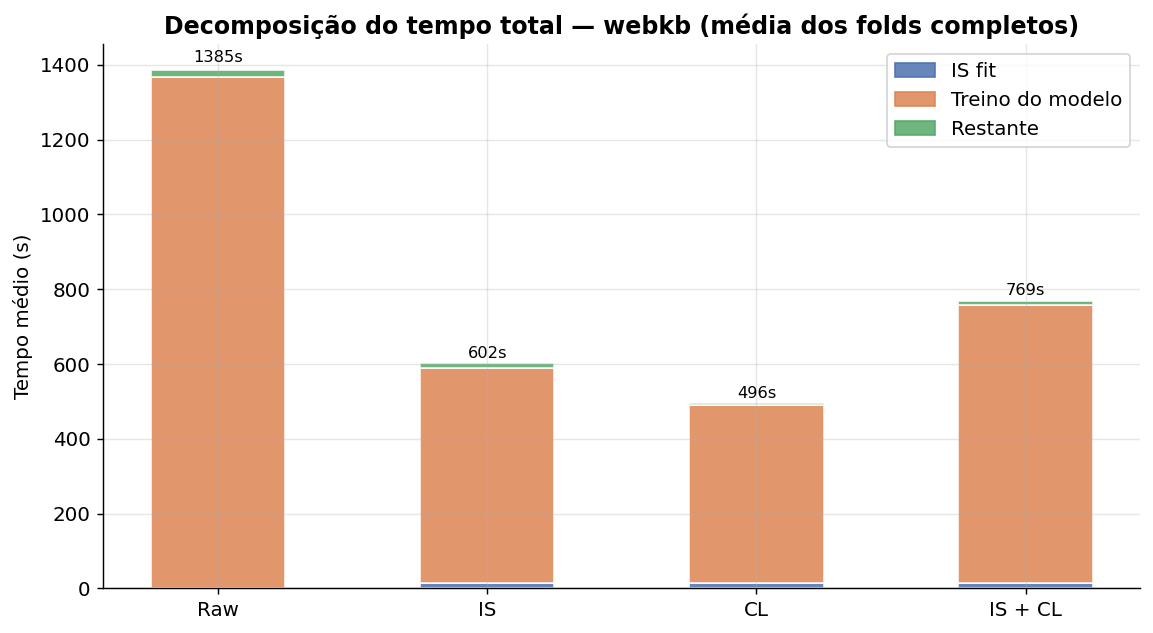

In [5]:
import matplotlib.patches as mpatches

DECOMP_DATASET = 'webkb'

def _mean_or_zero(sub_df, col):
    if col not in sub_df.columns:
        return 0.0
    m = sub_df[col].mean()
    return 0.0 if pd.isna(m) else float(m)

fig, ax = plt.subplots(figsize=(9, 5))

comp_colors = ['#4C72B0', '#DD8452', '#55A868']
comp_labels = ['IS fit', 'Treino do modelo', 'Restante']
width = 0.5

x = np.arange(len(MODES))
for idx, mode in enumerate(MODES):
    sub = df_timings[
        (df_timings['dataset'] == DECOMP_DATASET) &
        (df_timings['mode'] == mode) &
        (df_timings['fold'].isin(complete_folds[(DECOMP_DATASET, mode)]))
    ]
    total_mean = _mean_or_zero(sub, 'total_run_time_s')
    is_fit  = _mean_or_zero(sub, 'is_fit_time_s')
    train_t = _mean_or_zero(sub, 'model_train_time_s')
    rest    = max(0.0, total_mean - is_fit - train_t)

    bottom = 0.0
    for val, color in zip([is_fit, train_t, rest], comp_colors):
        ax.bar(idx, val, width, bottom=bottom, color=color, alpha=0.85, edgecolor='white')
        bottom += val

    ax.text(idx, total_mean + max(total_mean * 0.01, 2), f'{total_mean:.0f}s',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([MODE_LABELS[m] for m in MODES])
ax.set_ylabel('Tempo médio (s)')
ax.set_title(f'Decomposição do tempo total — {DECOMP_DATASET} (média dos folds completos)',
             fontweight='bold')
patches = [mpatches.Patch(color=c, label=l, alpha=0.85)
           for c, l in zip(comp_colors, comp_labels)]
ax.legend(handles=patches, loc='upper right')
plt.tight_layout()
plt.show()

### 2.2 Instâncias de treino por modo — WebKB

**Atenção a um detalhe sutil**: a coluna `n_samples` no `phase_metrics.csv` significa coisas diferentes:
- `raw`/`is` (em `cli.py::_eval_single_stage`): `n_samples = len(y_test)` — **tamanho do TESTE**
- `cl`/`is_cl` (em `biois_curriculum.py:234`): `n_samples = len(indices)` da fase — **tamanho do TREINO**

Para deixar comparável, derivo o tamanho do treino de forma uniforme via `n_iter` (que é o `global_step_` cumulativo do otimizador) e o `batch_size` do config:
- `raw`/`is` (1 fase): `train = n_iter × batch_size / epochs`
- `cl`/`is_cl` (cumulativo): `train = n_samples` da fase `hard` (já contém todas as instâncias)

Dois painéis:
- **Esquerda** — instâncias únicas no treino. Esperado: `raw ≈ cl` (≈ full set) > `is ≈ is_cl` (≈ subset BIOIS, ~50% menor pelo `beta=0.3, theta=0.2`).
- **Direita** — samples-época total (`n_iter × batch_size` da última fase, com `n_iter` cumulativo). Mede o trabalho real do modelo, contando as revisitas do currículo.

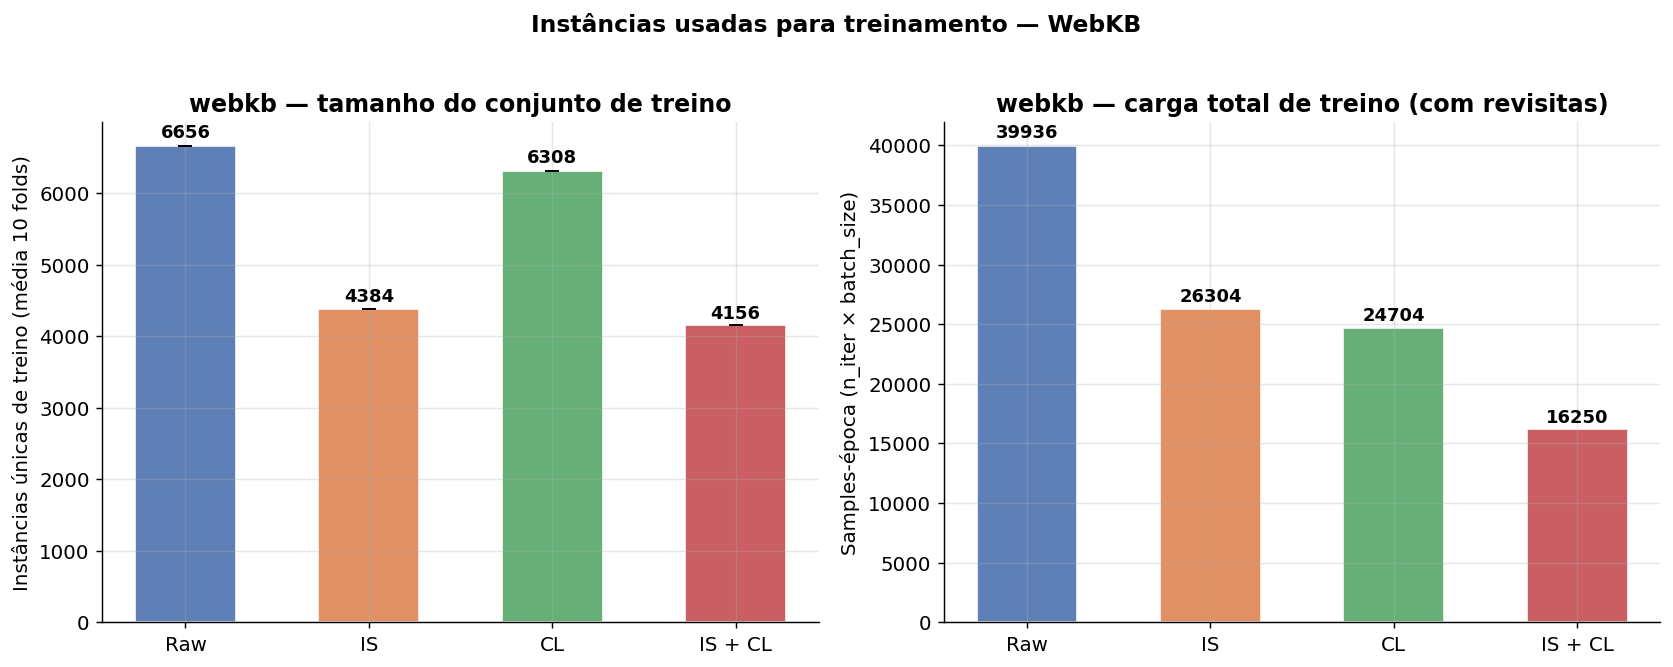


Resumo (média 10 folds completos):
  Raw      | instâncias únicas =    6656 ±     0  |  samples-época =    39936
  IS       | instâncias únicas =    4384 ±     0  |  samples-época =    26304
  CL       | instâncias únicas =    6308 ±     1  |  samples-época =    24704
  IS + CL  | instâncias únicas =    4156 ±     3  |  samples-época =    16250


In [6]:
import matplotlib.patches as mpatches

INSTANCES_DATASET = 'webkb'

# Lê batch_size / epochs / epochs_per_phase do primeiro config.json disponível por modo.
# n_samples no phase_metrics é tamanho do TESTE para raw/is (bug do _eval_single_stage)
# e tamanho do TREINO por fase (cumulativa) para cl/is_cl. Para ser consistente, derivamos
# o tamanho real do treino a partir de n_iter (=global_step_) e batch_size.
import json as _json
def _read_cfg(mode):
    run = RUN_DIRS[INSTANCES_DATASET].get(mode)
    if run is None:
        return None
    for k in range(N_FOLDS):
        f = run / f'{mode}_fold{k}' / 'config.json'
        if f.exists():
            return _json.loads(f.read_text())
    return None

CFG = {m: _read_cfg(m) for m in MODES}

def _train_size_per_fold(mode):
    """Tamanho efetivo do conjunto de treino (instâncias únicas) por fold.

    raw/is: derivado de n_iter (global_step_) * batch_size / epochs.
    cl/is_cl: n_samples da fase 'hard' (cumulativa, contém todas as instâncias
              que entraram no currículo após a redução IS).
    """
    cfg = CFG[mode] or {}
    bs = cfg.get('batch_size', 32)
    sub = df_pm[
        (df_pm['dataset'] == INSTANCES_DATASET) &
        (df_pm['mode'] == mode) &
        (df_pm['fold'].isin(complete_folds[(INSTANCES_DATASET, mode)]))
    ]
    if mode in ('raw', 'is'):
        ep = cfg.get('epochs', 6)
        full = sub[sub['phase'] == 'full']
        # n_iter aqui é global_step_ total da fase única
        return (full['n_iter'].astype(float) * bs / ep).to_numpy()
    else:  # cl, is_cl — fase hard contém todas as instâncias do currículo
        hard = sub[sub['phase'] == 'hard']
        return hard['n_samples'].astype(float).to_numpy()

def _workload_per_fold(mode):
    """Samples-época total (n_iter cumulativo × batch_size).

    n_iter no phase_metrics é cumulativo (global_step_), então para cl/is_cl
    o n_iter da fase 'hard' já é o total de steps. Multiplicado por batch_size
    dá o número total de instâncias processadas (com revisitas do currículo).
    """
    cfg = CFG[mode] or {}
    bs = cfg.get('batch_size', 32)
    sub = df_pm[
        (df_pm['dataset'] == INSTANCES_DATASET) &
        (df_pm['mode'] == mode) &
        (df_pm['fold'].isin(complete_folds[(INSTANCES_DATASET, mode)]))
    ]
    if mode in ('raw', 'is'):
        last = sub[sub['phase'] == 'full']
    else:
        last = sub[sub['phase'] == 'hard']
    return (last['n_iter'].astype(float) * bs).to_numpy()

train_sizes = {m: _train_size_per_fold(m) for m in MODES}
workloads   = {m: _workload_per_fold(m)   for m in MODES}

train_mean  = {m: float(np.nanmean(v)) if len(v) else float('nan') for m, v in train_sizes.items()}
train_std   = {m: float(np.nanstd(v, ddof=1)) if len(v) > 1 else 0.0 for m, v in train_sizes.items()}
work_mean   = {m: float(np.nanmean(v)) if len(v) else float('nan') for m, v in workloads.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- (a) Instâncias únicas de treino ---
ax = axes[0]
x = np.arange(len(MODES))
width = 0.55
means = [train_mean[m] for m in MODES]
stds  = [train_std[m]  for m in MODES]
colors = [MODE_COLORS[m] for m in MODES]
ax.bar(x, means, width, yerr=stds, color=colors, alpha=0.9,
       edgecolor='white', linewidth=1, capsize=4)
for xi, m, mn in zip(x, MODES, means):
    ax.text(xi, mn + mn * 0.01, f'{mn:.0f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([MODE_LABELS[m] for m in MODES])
ax.set_ylabel('Instâncias únicas de treino (média 10 folds)')
ax.set_title(f'{INSTANCES_DATASET} — tamanho do conjunto de treino',
             fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# --- (b) Workload total (samples-época) ---
ax = axes[1]
work_vals = [work_mean[m] for m in MODES]
ax.bar(x, work_vals, width, color=colors, alpha=0.9,
       edgecolor='white', linewidth=1)
for xi, m, wv in zip(x, MODES, work_vals):
    ax.text(xi, wv + wv * 0.01, f'{wv:.0f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([MODE_LABELS[m] for m in MODES])
ax.set_ylabel('Samples-época (n_iter × batch_size)')
ax.set_title(f'{INSTANCES_DATASET} — carga total de treino (com revisitas)',
             fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Instâncias usadas para treinamento — WebKB',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nResumo (média 10 folds completos):')
for m in MODES:
    print(f'  {MODE_LABELS[m]:8s} | instâncias únicas = {train_mean[m]:7.0f} ± {train_std[m]:5.0f}'
          f'  |  samples-época = {work_mean[m]:8.0f}')

## 3. Projeto 2² — Análise fatorial (IS × CL) por dataset

Os 4 modos formam um delineamento fatorial 2² com:
- Fator **A = IS** (Instance Selection): 0 = não, 1 = sim
- Fator **B = CL** (Curriculum Learning): 0 = não, 1 = sim

| Modo | IS (A) | CL (B) |
|------|--------|--------|
| raw   | 0 | 0 |
| is    | 1 | 0 |
| cl    | 0 | 1 |
| is_cl | 1 | 1 |

Duas respostas avaliadas por dataset:
- **macro-F1** (`macro_f1` da última fase de avaliação)
- **tempo de treino** (`model_train_time_s`)

Usamos apenas folds completos por célula. ANOVA com **SS Tipo III** (modelos aninhados via lstsq) e codificação ±1 (efeitos).

In [7]:
FACTOR_MAP = {
    'raw':   (0, 0),
    'is':    (1, 0),
    'cl':    (0, 1),
    'is_cl': (1, 1),
}

def _fit_ss_res(X, y):
    coef, _, _, _ = lstsq(X, y, rcond=None)
    return np.sum((y - X @ coef) ** 2)

def factorial_2x2(values_by_mode, response_name):
    """values_by_mode: {mode: np.array de respostas (1 valor por fold completo)}.

    Retorna dict com: cell_means, effects, anova_df, pct_var.
    """
    rows = []
    for mode, vals in values_by_mode.items():
        A, B = FACTOR_MAP[mode]
        for v in vals:
            if np.isfinite(v):
                rows.append({'mode': mode, 'IS': A, 'CL': B,
                             'A': -1 if A == 0 else 1, 'B': -1 if B == 0 else 1,
                             response_name: v})
    df = pd.DataFrame(rows)
    if df.empty:
        return None
    df['AB'] = df['A'] * df['B']

    y    = df[response_name].values
    n    = len(y)
    gm   = y.mean()
    ones = np.ones(n)
    A_   = df['A'].values
    B_   = df['B'].values
    AB_  = df['AB'].values

    X_full = np.column_stack([ones, A_, B_, AB_])
    ss_res_full = _fit_ss_res(X_full, y)
    ss_res_noA  = _fit_ss_res(np.column_stack([ones, B_, AB_]), y)
    ss_res_noB  = _fit_ss_res(np.column_stack([ones, A_, AB_]), y)
    ss_res_noAB = _fit_ss_res(np.column_stack([ones, A_, B_]),  y)

    ss_A  = ss_res_noA  - ss_res_full
    ss_B  = ss_res_noB  - ss_res_full
    ss_AB = ss_res_noAB - ss_res_full
    ss_tot = np.sum((y - gm) ** 2)
    ss_res = ss_res_full

    pct_A  = 100 * ss_A  / ss_tot if ss_tot > 0 else float('nan')
    pct_B  = 100 * ss_B  / ss_tot if ss_tot > 0 else float('nan')
    pct_AB = 100 * ss_AB / ss_tot if ss_tot > 0 else float('nan')
    pct_e  = 100 * ss_res / ss_tot if ss_tot > 0 else float('nan')

    cell = df.groupby(['IS', 'CL'])[response_name].mean()
    y00, y10 = cell.get((0, 0), np.nan), cell.get((1, 0), np.nan)
    y01, y11 = cell.get((0, 1), np.nan), cell.get((1, 1), np.nan)
    eA  = 0.5 * ((y10 - y00) + (y11 - y01))
    eB  = 0.5 * ((y01 - y00) + (y11 - y10))
    eAB = 0.5 * ((y11 - y01) - (y10 - y00))

    gl_e = n - 4
    ms_e = ss_res / gl_e if gl_e > 0 else float('nan')
    anova = pd.DataFrame([
        {'Fonte': 'A — IS',          'SS': ss_A,  'GL': 1,    'MS': ss_A,
         'Efeito': eA,  '% var': pct_A,  'F': ss_A / ms_e if ms_e else np.nan,
         'p-valor': (1 - stats.f.cdf(ss_A / ms_e, 1, gl_e)) if (ms_e and gl_e > 0) else np.nan},
        {'Fonte': 'B — CL',          'SS': ss_B,  'GL': 1,    'MS': ss_B,
         'Efeito': eB,  '% var': pct_B,  'F': ss_B / ms_e if ms_e else np.nan,
         'p-valor': (1 - stats.f.cdf(ss_B / ms_e, 1, gl_e)) if (ms_e and gl_e > 0) else np.nan},
        {'Fonte': 'AB — IS×CL',      'SS': ss_AB, 'GL': 1,    'MS': ss_AB,
         'Efeito': eAB, '% var': pct_AB, 'F': ss_AB / ms_e if ms_e else np.nan,
         'p-valor': (1 - stats.f.cdf(ss_AB / ms_e, 1, gl_e)) if (ms_e and gl_e > 0) else np.nan},
        {'Fonte': 'Erro (resíduo)',  'SS': ss_res, 'GL': gl_e, 'MS': ms_e,
         'Efeito': np.nan, '% var': pct_e, 'F': np.nan, 'p-valor': np.nan},
        {'Fonte': 'Total',           'SS': ss_tot, 'GL': n - 1, 'MS': np.nan,
         'Efeito': np.nan, '% var': pct_A + pct_B + pct_AB + pct_e,
         'F': np.nan, 'p-valor': np.nan},
    ]).set_index('Fonte')

    return {
        'df': df, 'n': n,
        'cell_means': {'raw': y00, 'is': y10, 'cl': y01, 'is_cl': y11},
        'effects':    {'A': eA, 'B': eB, 'AB': eAB},
        'pct_var':    {'A': pct_A, 'B': pct_B, 'AB': pct_AB, 'erro': pct_e},
        'anova':      anova,
    }

def plot_factorial(res, response_label, response_unit, suptitle):
    if res is None:
        print('Sem dados para plotar.')
        return
    df = res['df']
    response_col = [c for c in df.columns if c not in ('mode', 'IS', 'CL', 'A', 'B', 'AB')][0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

    # (a) Efeito de IS por nível de CL
    ax = axes[0]
    for cl_val, ls, lbl in [(0, '-o', 'CL=0'), (1, '-s', 'CL=1')]:
        sub = df[df['CL'] == cl_val]
        if sub.empty:
            continue
        grp = sub.groupby('IS')[response_col].agg(['mean', 'std', 'count'])
        grp['se'] = grp['std'] / np.sqrt(grp['count'])
        grp['h']  = grp['se'] * stats.t.ppf(1 - CI_ALPHA / 2, df=np.maximum(grp['count'] - 1, 1))
        ax.errorbar(grp.index, grp['mean'], yerr=grp['h'], fmt=ls,
                    capsize=5, linewidth=2, markersize=8, label=lbl)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['IS=0', 'IS=1'])
    ax.set_ylabel(f'{response_label} ({response_unit})' if response_unit else response_label)
    ax.set_title('Efeito de IS\n(por nível de CL)', fontweight='bold')
    ax.legend()

    # (b) Efeito de CL por nível de IS
    ax = axes[1]
    for is_val, ls, lbl in [(0, '-o', 'IS=0'), (1, '-s', 'IS=1')]:
        sub = df[df['IS'] == is_val]
        if sub.empty:
            continue
        grp = sub.groupby('CL')[response_col].agg(['mean', 'std', 'count'])
        grp['se'] = grp['std'] / np.sqrt(grp['count'])
        grp['h']  = grp['se'] * stats.t.ppf(1 - CI_ALPHA / 2, df=np.maximum(grp['count'] - 1, 1))
        ax.errorbar(grp.index, grp['mean'], yerr=grp['h'], fmt=ls,
                    capsize=5, linewidth=2, markersize=8, label=lbl)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['CL=0', 'CL=1'])
    ax.set_ylabel(f'{response_label} ({response_unit})' if response_unit else response_label)
    ax.set_title('Efeito de CL\n(por nível de IS)', fontweight='bold')
    ax.legend()

    # (c) Pie de variância explicada
    ax = axes[2]
    pv = res['pct_var']
    labels_pie = ['IS (A)', 'CL (B)', 'IS×CL (AB)', 'Erro']
    sizes_pie  = [pv['A'], pv['B'], pv['AB'], pv['erro']]
    colors_pie = ['#4C72B0', '#55A868', '#C44E52', '#CCCCCC']
    ax.pie(sizes_pie, labels=labels_pie, autopct='%1.1f%%',
           colors=colors_pie, startangle=90,
           wedgeprops=dict(edgecolor='white', linewidth=1.5))
    ax.set_title('Variância explicada\n(SS / SS_total)', fontweight='bold')

    plt.suptitle(suptitle, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def print_factorial_summary(res, response_label, unit_fmt='{:.5f}'):
    if res is None:
        print('Sem dados.')
        return
    cm = res['cell_means']; ef = res['effects']; pv = res['pct_var']
    print(f"N = {res['n']} observações")
    print('\nMédias por célula:')
    print(f"  raw    (IS=0, CL=0): {unit_fmt.format(cm['raw'])}")
    print(f"  is     (IS=1, CL=0): {unit_fmt.format(cm['is'])}")
    print(f"  cl     (IS=0, CL=1): {unit_fmt.format(cm['cl'])}")
    print(f"  is_cl  (IS=1, CL=1): {unit_fmt.format(cm['is_cl'])}")
    print('\nEfeitos:')
    print(f"  A (IS):     {ef['A']:+.6f}")
    print(f"  B (CL):     {ef['B']:+.6f}")
    print(f"  AB (IS×CL): {ef['AB']:+.6f}")
    print('\nVariância explicada:')
    print(f"  A (IS):       {pv['A']:.2f}%")
    print(f"  B (CL):       {pv['B']:.2f}%")
    print(f"  AB (IS×CL):   {pv['AB']:.2f}%")
    print(f"  Erro/resíduo: {pv['erro']:.2f}%")

def run_dataset_factorial(ds):
    """Executa 2² para macro_f1 e model_train_time_s no dataset, retorna (res_f1, res_time)."""
    f1_by_mode = {
        m: np.array([
            fold_metric_value(ds, m, k, 'macro_f1')
            for k in complete_folds[(ds, m)]
        ])
        for m in MODES
    }
    t_by_mode  = {
        m: np.array([
            fold_time_value(ds, m, k, 'model_train_time_s')
            for k in complete_folds[(ds, m)]
        ])
        for m in MODES
    }
    res_f1   = factorial_2x2(f1_by_mode, 'macro_f1')
    res_time = factorial_2x2(t_by_mode,  'model_train_time_s')
    return res_f1, res_time

factorial_results = {}
for ds in DATASETS:
    factorial_results[ds] = run_dataset_factorial(ds)
print('Análises 2² calculadas para:', list(factorial_results))

Análises 2² calculadas para: ['webkb', 'mpqa', 'reuters90']


### 3.1 WebKB

=== WebKB | Resposta: macro-F1 ===
N = 40 observações

Médias por célula:
  raw    (IS=0, CL=0): 0.82741
  is     (IS=1, CL=0): 0.80734
  cl     (IS=0, CL=1): 0.73403
  is_cl  (IS=1, CL=1): 0.69944

Efeitos:
  A (IS):     -0.027326
  B (CL):     -0.100637
  AB (IS×CL): -0.007260

Variância explicada:
  A (IS):       6.03%
  B (CL):       81.77%
  AB (IS×CL):   0.43%
  Erro/resíduo: 11.77%


,SS,GL,MS,Efeito,% var,F,p-valor
Fonte,,,,,,,
A — IS,0.007467,1,0.007467,-0.027326,6.028922,18.439278,0.000127
B — CL,0.101279,1,0.101279,-0.100637,81.774860,250.105969,0.000000
AB — IS×CL,0.000527,1,0.000527,-0.007260,0.425628,1.301770,0.261423
Erro (resíduo),0.014578,36,0.000405,NaN,11.770591,NaN,NaN
Total,0.123851,39,NaN,NaN,100.000000,NaN,NaN


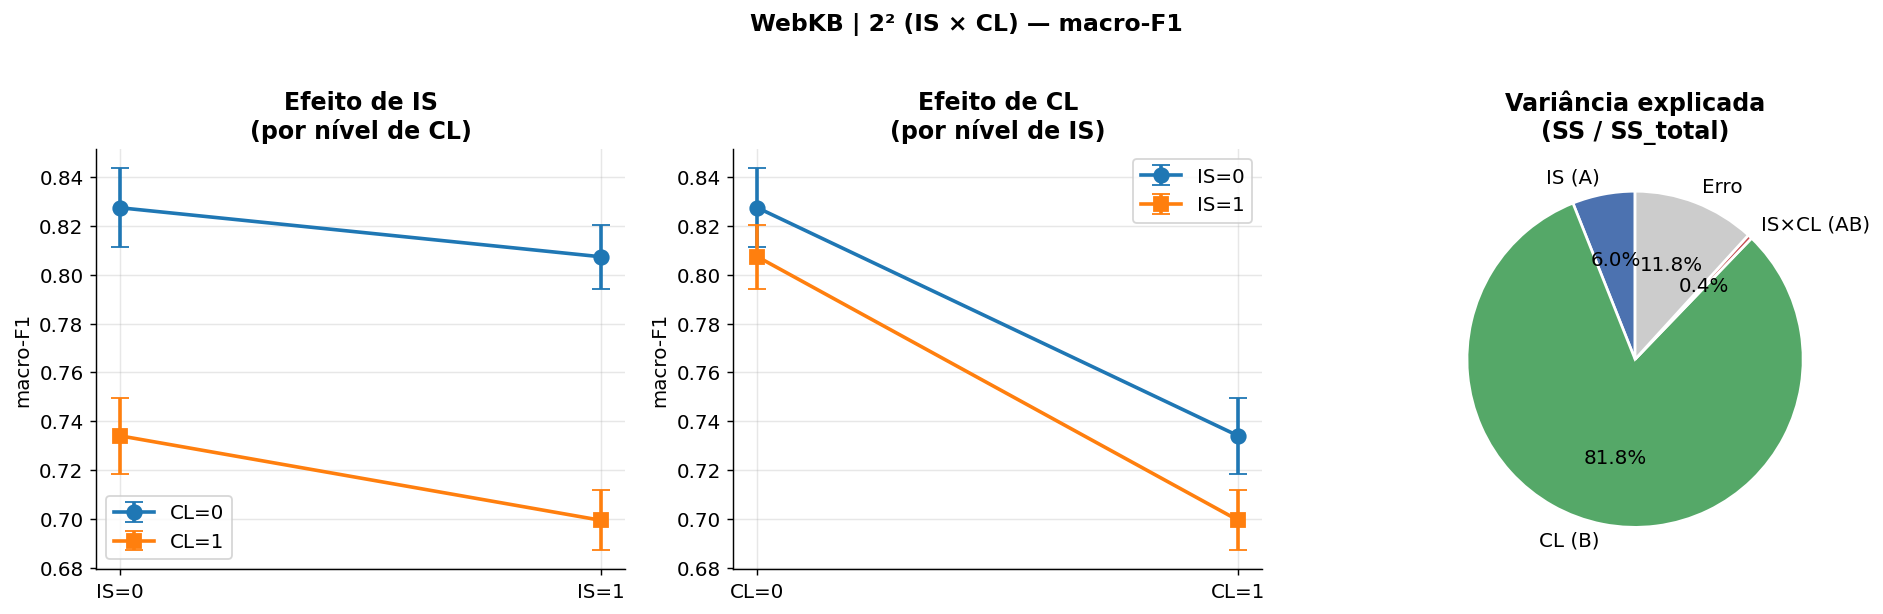


=== WebKB | Resposta: tempo de treino (s) ===
N = 40 observações

Médias por célula:
  raw    (IS=0, CL=0): 1367.52
  is     (IS=1, CL=0): 574.80
  cl     (IS=0, CL=1): 475.33
  is_cl  (IS=1, CL=1): 742.11

Efeitos:
  A (IS):     -262.964498
  B (CL):     -362.441698
  AB (IS×CL): +529.751387

Variância explicada:
  A (IS):       12.16%
  B (CL):       23.10%
  AB (IS×CL):   49.35%
  Erro/resíduo: 15.38%


,SS,GL,MS,Efeito,% var,F,p-valor
Fonte,,,,,,,
A — IS,6.915033e+05,1,6.915033e+05,-262.9645,12.1608,28.4568,0.0
B — CL,1.313640e+06,1,1.313640e+06,-362.4417,23.1018,54.0591,0.0
AB — IS×CL,2.806365e+06,1,2.806365e+06,529.7514,49.3530,115.4879,0.0
Erro (resíduo),8.748028e+05,36,2.430008e+04,NaN,15.3844,NaN,NaN
Total,5.686311e+06,39,NaN,NaN,100.0000,NaN,NaN


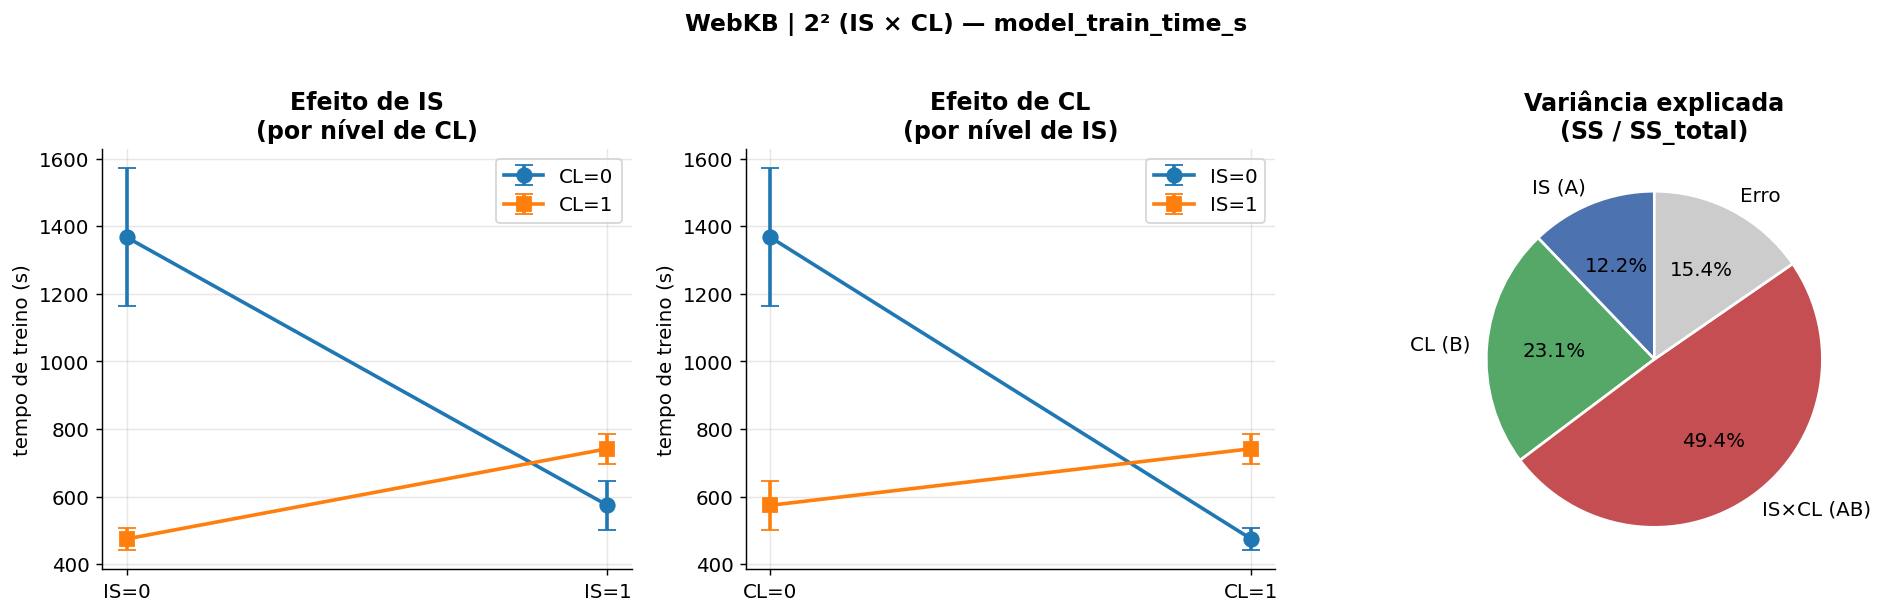

In [8]:
res_f1, res_time = factorial_results['webkb']

print('=== WebKB | Resposta: macro-F1 ===')
print_factorial_summary(res_f1, 'macro-F1', '{:.5f}')
display(res_f1['anova'].round(6))
plot_factorial(res_f1, 'macro-F1', '', 'WebKB | 2² (IS × CL) — macro-F1')

print('\n=== WebKB | Resposta: tempo de treino (s) ===')
print_factorial_summary(res_time, 'model_train_time_s', '{:.2f}')
display(res_time['anova'].round(4))
plot_factorial(res_time, 'tempo de treino', 's', 'WebKB | 2² (IS × CL) — model_train_time_s')

### 3.2 MPQA

=== MPQA | Resposta: macro-F1 ===
N = 40 observações

Médias por célula:
  raw    (IS=0, CL=0): 0.89632
  is     (IS=1, CL=0): 0.89204
  cl     (IS=0, CL=1): 0.88955
  is_cl  (IS=1, CL=1): 0.88990

Efeitos:
  A (IS):     -0.001966
  B (CL):     -0.004459
  AB (IS×CL): +0.002310

Variância explicada:
  A (IS):       0.85%
  B (CL):       4.35%
  AB (IS×CL):   1.17%
  Erro/resíduo: 93.63%


,SS,GL,MS,Efeito,% var,F,p-valor
Fonte,,,,,,,
A — IS,0.000039,1,0.000039,-0.001966,0.846662,0.325536,0.571844
B — CL,0.000199,1,0.000199,-0.004459,4.354756,1.674376,0.203914
AB — IS×CL,0.000053,1,0.000053,0.002310,1.168947,0.449453,0.506873
Erro (resíduo),0.004274,36,0.000119,NaN,93.629635,NaN,NaN
Total,0.004565,39,NaN,NaN,100.000000,NaN,NaN


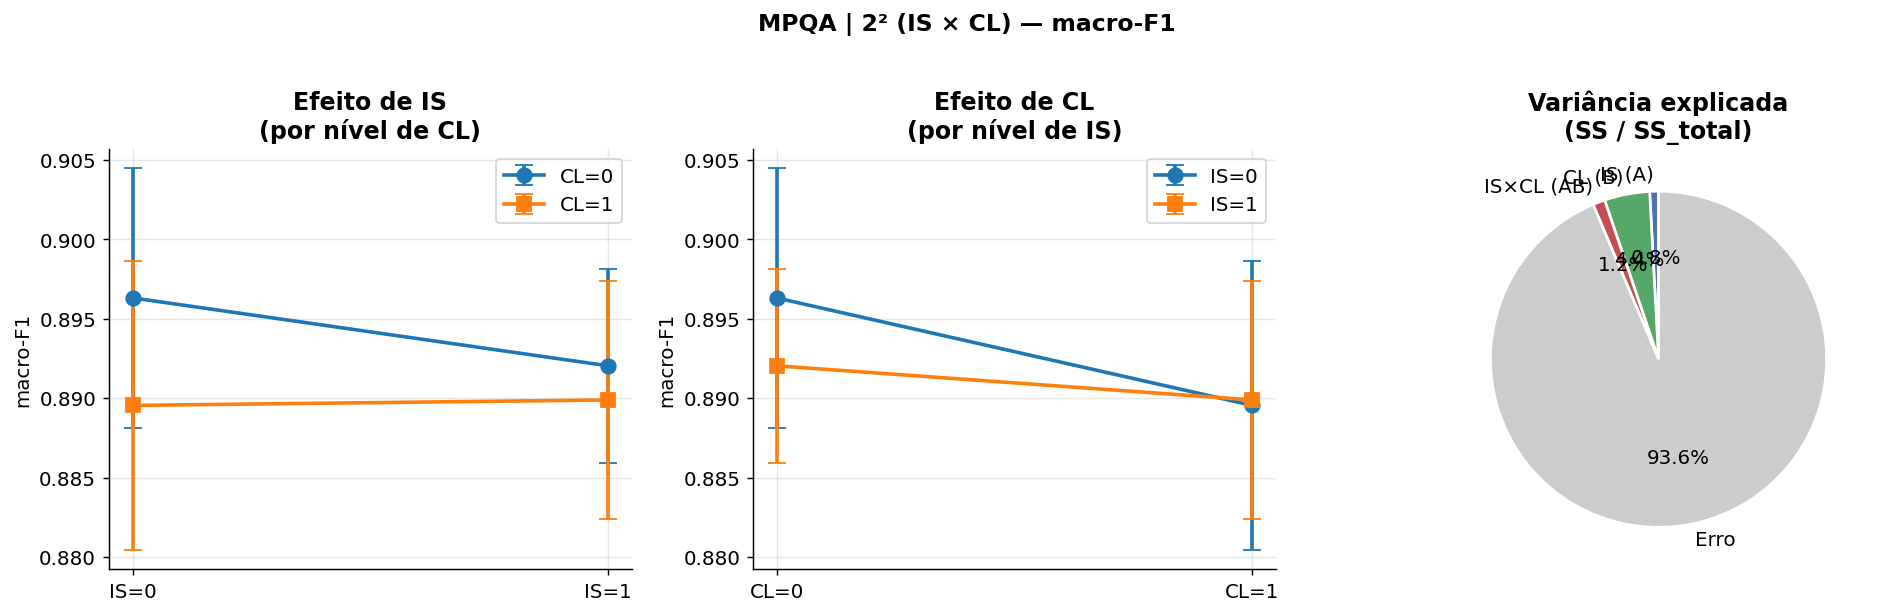


=== MPQA | Resposta: tempo de treino (s) ===
N = 40 observações

Médias por célula:
  raw    (IS=0, CL=0): 329.96
  is     (IS=1, CL=0): 125.48
  cl     (IS=0, CL=1): 126.25
  is_cl  (IS=1, CL=1): 86.14

Efeitos:
  A (IS):     -122.291380
  B (CL):     -121.524080
  AB (IS×CL): +82.187617

Variância explicada:
  A (IS):       40.54%
  B (CL):       40.03%
  AB (IS×CL):   18.31%
  Erro/resíduo: 1.13%


,SS,GL,MS,Efeito,% var,F,p-valor
Fonte,,,,,,,
A — IS,149551.8169,1,149551.8169,-122.2914,40.5357,1294.9100,0.0
B — CL,147681.0203,1,147681.0203,-121.5241,40.0286,1278.7116,0.0
AB — IS×CL,67548.0434,1,67548.0434,82.1876,18.3087,584.8718,0.0
Erro (resíduo),4157.7138,36,115.4921,NaN,1.1269,NaN,NaN
Total,368938.5944,39,NaN,NaN,100.0000,NaN,NaN


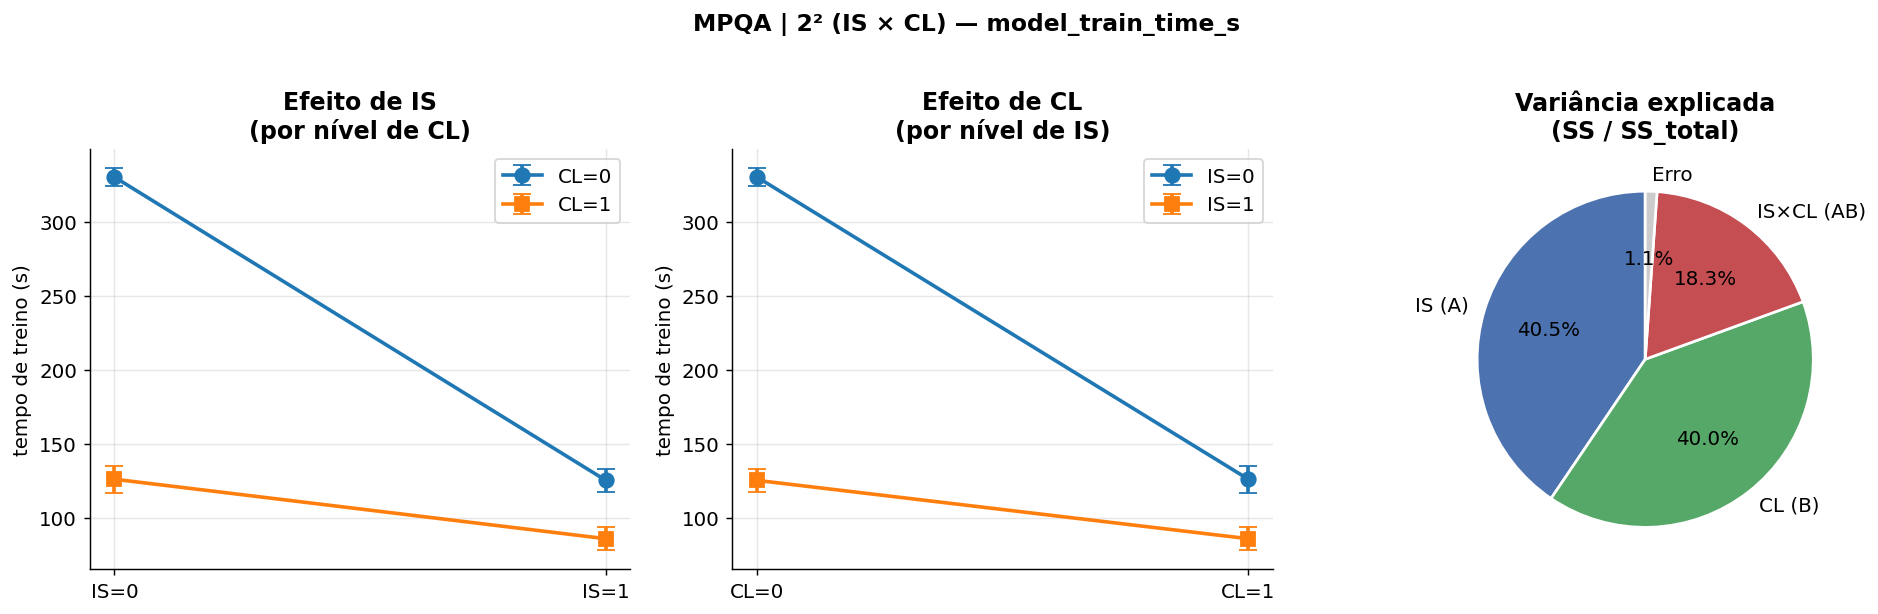

In [9]:
res_f1, res_time = factorial_results['mpqa']

print('=== MPQA | Resposta: macro-F1 ===')
print_factorial_summary(res_f1, 'macro-F1', '{:.5f}')
display(res_f1['anova'].round(6))
plot_factorial(res_f1, 'macro-F1', '', 'MPQA | 2² (IS × CL) — macro-F1')

print('\n=== MPQA | Resposta: tempo de treino (s) ===')
print_factorial_summary(res_time, 'model_train_time_s', '{:.2f}')
display(res_time['anova'].round(4))
plot_factorial(res_time, 'tempo de treino', 's', 'MPQA | 2² (IS × CL) — model_train_time_s')

### 3.3 Reuters90

=== Reuters90 | Resposta: macro-F1 ===
N = 32 observações

Médias por célula:
  raw    (IS=0, CL=0): 0.46562
  is     (IS=1, CL=0): 0.43310
  cl     (IS=0, CL=1): 0.38200
  is_cl  (IS=1, CL=1): 0.37213

Efeitos:
  A (IS):     -0.021196
  B (CL):     -0.072296
  AB (IS×CL): +0.011320

Variância explicada:
  A (IS):       5.04%
  B (CL):       58.65%
  AB (IS×CL):   1.44%
  Erro/resíduo: 34.87%


,SS,GL,MS,Efeito,% var,F,p-valor
Fonte,,,,,,,
A — IS,0.003594,1,0.003594,-0.021196,5.041690,4.048716,0.053915
B — CL,0.041813,1,0.041813,-0.072296,58.653202,47.101304,0.000000
AB — IS×CL,0.001025,1,0.001025,0.011320,1.437927,1.154724,0.291736
Erro (resíduo),0.024856,28,0.000888,NaN,34.867181,NaN,NaN
Total,0.071289,31,NaN,NaN,100.000000,NaN,NaN


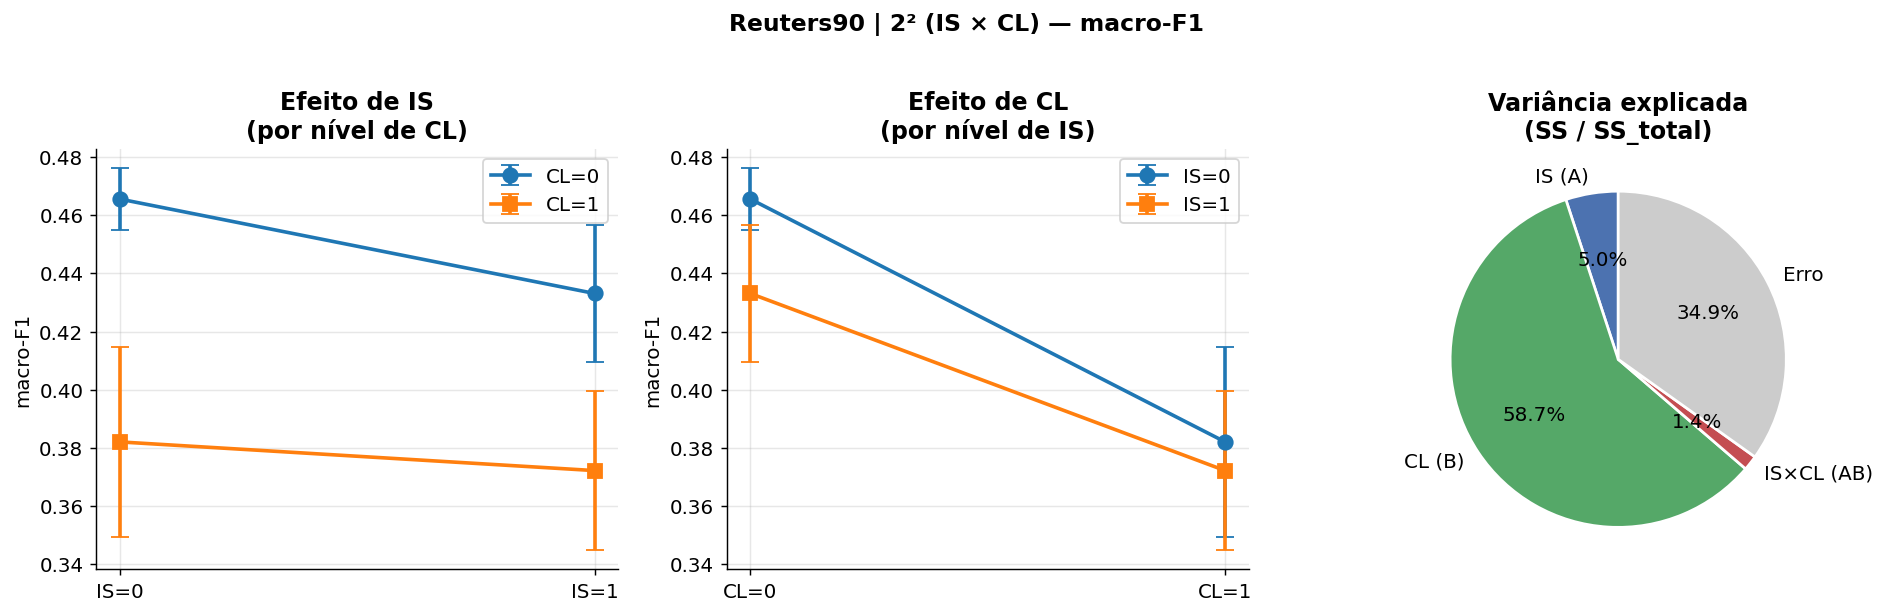


=== Reuters90 | Resposta: tempo de treino (s) ===
N = 32 observações

Médias por célula:
  raw    (IS=0, CL=0): 1910.91
  is     (IS=1, CL=0): 887.77
  cl     (IS=0, CL=1): 1309.05
  is_cl  (IS=1, CL=1): 779.55

Efeitos:
  A (IS):     -776.317474
  B (CL):     -355.038320
  AB (IS×CL): +246.824957

Variância explicada:
  A (IS):       40.23%
  B (CL):       8.41%
  AB (IS×CL):   4.07%
  Erro/resíduo: 47.29%


,SS,GL,MS,Efeito,% var,F,p-valor
Fonte,,,,,,,
A — IS,4.821351e+06,1,4.821351e+06,-776.3175,40.2301,23.8206,0.0000
B — CL,1.008418e+06,1,1.008418e+06,-355.0383,8.4144,4.9822,0.0338
AB — IS×CL,4.873805e+05,1,4.873805e+05,246.8250,4.0668,2.4080,0.1319
Erro (resíduo),5.667282e+06,28,2.024029e+05,NaN,47.2887,NaN,NaN
Total,1.198443e+07,31,NaN,NaN,100.0000,NaN,NaN


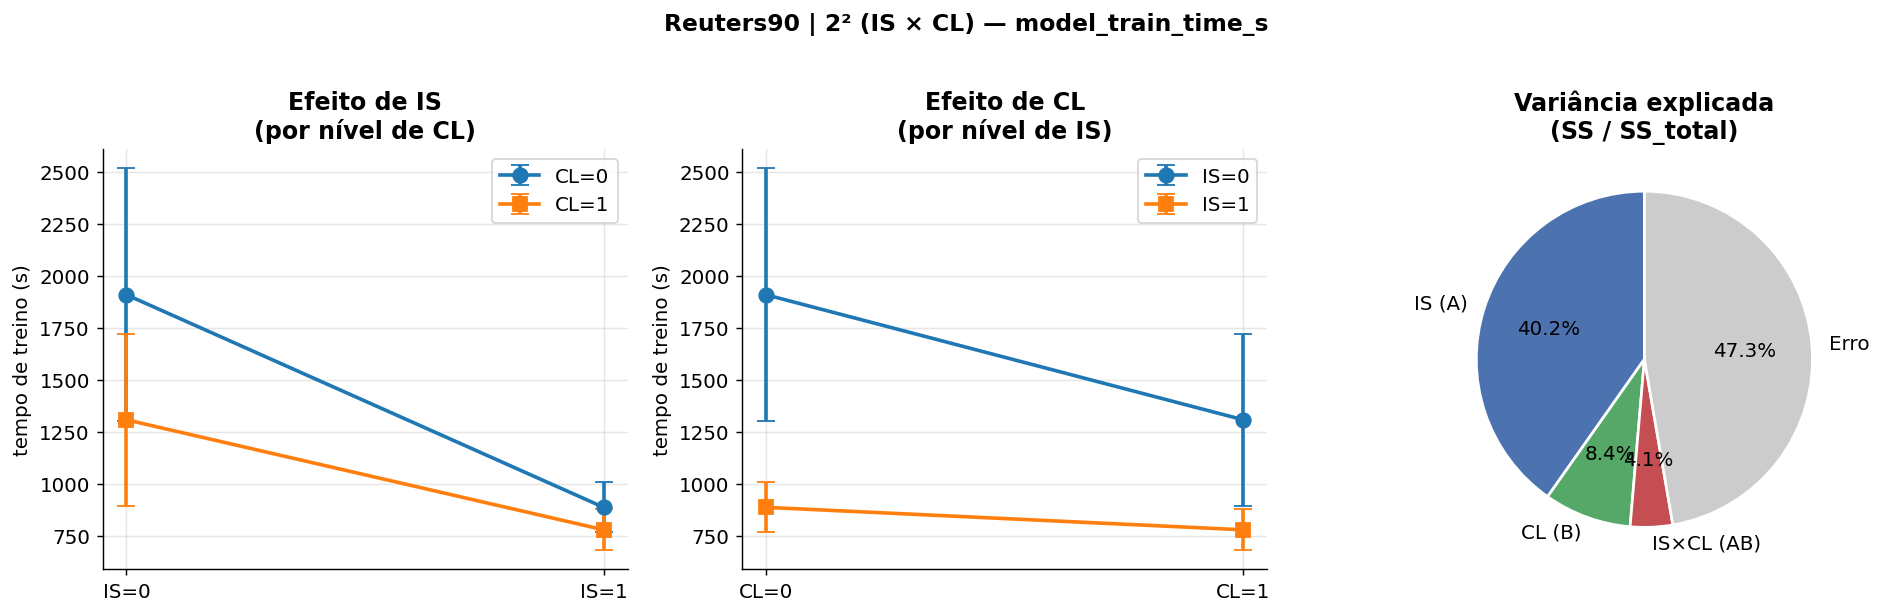

In [10]:
res_f1, res_time = factorial_results['reuters90']

print('=== Reuters90 | Resposta: macro-F1 ===')
print_factorial_summary(res_f1, 'macro-F1', '{:.5f}')
display(res_f1['anova'].round(6))
plot_factorial(res_f1, 'macro-F1', '', 'Reuters90 | 2² (IS × CL) — macro-F1')

print('\n=== Reuters90 | Resposta: tempo de treino (s) ===')
print_factorial_summary(res_time, 'model_train_time_s', '{:.2f}')
display(res_time['anova'].round(4))
plot_factorial(res_time, 'tempo de treino', 's', 'Reuters90 | 2² (IS × CL) — model_train_time_s')

## 4. Resumo consolidado dos efeitos (3 datasets × 2 respostas)

In [11]:
consol = []
for ds in DATASETS:
    res_f1, res_time = factorial_results[ds]
    for resp_label, res in [('macro_f1', res_f1), ('model_train_time_s', res_time)]:
        if res is None:
            continue
        anova = res['anova']
        consol.append({
            'dataset': ds,
            'resposta': resp_label,
            'efeito_IS': res['effects']['A'],
            'efeito_CL': res['effects']['B'],
            'efeito_ISxCL': res['effects']['AB'],
            '%var_IS':    res['pct_var']['A'],
            '%var_CL':    res['pct_var']['B'],
            '%var_ISxCL': res['pct_var']['AB'],
            '%var_erro':  res['pct_var']['erro'],
            'p_IS':    anova.loc['A — IS', 'p-valor'],
            'p_CL':    anova.loc['B — CL', 'p-valor'],
            'p_ISxCL': anova.loc['AB — IS×CL', 'p-valor'],
            'n_obs':   res['n'],
        })
df_consol = pd.DataFrame(consol)
display(df_consol.round(4))

# Salva no proprio performance.xlsx como aba extra
with pd.ExcelWriter(perf_xlsx, engine='openpyxl', mode='a', if_sheet_exists='replace') as w:
    df_consol.to_excel(w, sheet_name='2x2_resumo', index=False)
print(f'\nResumo 2² adicionado em {perf_xlsx.relative_to(PROJECT_ROOT)} (aba 2x2_resumo).')

,dataset,resposta,efeito_IS,efeito_CL,efeito_ISxCL,%var_IS,%var_CL,%var_ISxCL,%var_erro,p_IS,p_CL,p_ISxCL,n_obs
0,webkb,macro_f1,-0.0273,-0.1006,-0.0073,6.0289,81.7749,0.4256,11.7706,0.0001,0.0000,0.2614,40
1,webkb,model_train_time_s,-262.9645,-362.4417,529.7514,12.1608,23.1018,49.3530,15.3844,0.0000,0.0000,0.0000,40
2,mpqa,macro_f1,-0.0020,-0.0045,0.0023,0.8467,4.3548,1.1689,93.6296,0.5718,0.2039,0.5069,40
3,mpqa,model_train_time_s,-122.2914,-121.5241,82.1876,40.5357,40.0286,18.3087,1.1269,0.0000,0.0000,0.0000,40
4,reuters90,macro_f1,-0.0212,-0.0723,0.0113,5.0417,58.6532,1.4379,34.8672,0.0539,0.0000,0.2917,32
5,reuters90,model_train_time_s,-776.3175,-355.0383,246.8250,40.2301,8.4144,4.0668,47.2887,0.0000,0.0338,0.1319,32



Resumo 2² adicionado em analysis/performance.xlsx (aba 2x2_resumo).
